In [ ]:
# ============================================================
# Importing necessary libraries for data analysis and visualization
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("=" * 60)
print("A/B TEST ANALYSIS: CONVERSATION SCRIPTS")
print("=" * 60)
print("\n✓ Libraries loaded")

A/B TEST ANALYSIS: CONVERSATION SCRIPTS

✓ Libraries loaded


In [ ]:
# ============================================================
# Loading data
# ============================================================

df = pd.read_csv('../data/ab_test_data.csv')
df['call_date'] = pd.to_datetime(df['call_date'])

print("\n📊 Dataset Overview:")
print(f"  Total calls: {len(df):,}")
print(f"  Date range: {df['call_date'].min().date()} to {df['call_date'].max().date()}")
print(f"  Variants: {df['variant'].unique().tolist()}")

print("\n📋 Sample data:")
display(df.head(10))

print("\n📊 Basic statistics:")
display(df.groupby('variant').agg({
    'call_id': 'count',
    'is_contact': 'mean',
    'is_result': 'mean',
    'is_agreement': 'mean',
    'call_duration_sec': 'mean'
}).round(4))


📊 Dataset Overview:
  Total calls: 10,000
  Date range: 2025-02-01 to 2025-02-27
  Variants: ['Control', 'Treatment']

📋 Sample data:


,call_id,client_id,variant,call_date,call_hour,is_contact,is_result,is_agreement,call_duration_sec
0,C00000,C00000,Control,2025-02-07,16,1,0,0,114
1,C00001,C00001,Control,2025-02-23,10,0,0,0,214
2,C00002,C00002,Control,2025-02-04,11,0,0,0,152
3,C00003,C00003,Control,2025-02-06,9,0,0,0,145
4,C00004,C00004,Control,2025-02-01,12,0,0,0,98
5,C00005,C00005,Control,2025-02-27,13,1,0,0,133
6,C00006,C00006,Control,2025-02-15,13,0,0,0,152
7,C00007,C00007,Control,2025-02-25,9,0,0,0,107
8,C00008,C00008,Control,2025-02-21,13,1,0,0,89
9,C00009,C00009,Control,2025-02-26,10,0,0,0,183



📊 Basic statistics:


,call_id,is_contact,is_result,is_agreement,call_duration_sec
variant,,,,,
Control,5000,0.4466,0.0392,0.0282,149.6886
Treatment,5000,0.4652,0.0536,0.0370,119.9462


In [ ]:
# ============================================================
# Sample Ratio Mismatch (SRM) Check
# ============================================================

print("=" * 60)
print("SAMPLE RATIO MISMATCH CHECK")
print("=" * 60)

# Checking that both groups are approximately the same size
control_size = len(df[df['variant'] == 'Control'])
treatment_size = len(df[df['variant'] == 'Treatment'])

print(f"\n📊 Sample sizes:")
print(f"  Control: {control_size:,}")
print(f"  Treatment: {treatment_size:,}")
print(f"  Ratio: {control_size / treatment_size:.3f} (expected: 1.000)")

# Chi-squared test for checking uniformity of distribution
observed = [control_size, treatment_size]
expected = [len(df)/2, len(df)/2]

chi2, p_value = stats.chisquare(observed, expected)

print(f"\n🔬 Chi-squared test:")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {p_value:.4f}")

if p_value > 0.05:
    print(f"\n✅ PASS: Sample sizes are balanced (p > 0.05)")
else:
    print(f"\n⚠️  WARNING: Sample size imbalance detected (p < 0.05)")

SAMPLE RATIO MISMATCH CHECK

📊 Sample sizes:
  Control: 5,000
  Treatment: 5,000
  Ratio: 1.000 (expected: 1.000)

🔬 Chi-squared test:
  χ² = 0.0000
  p-value = 1.0000

✅ PASS: Sample sizes are balanced (p > 0.05)



DISTRIBUTION ANALYSIS


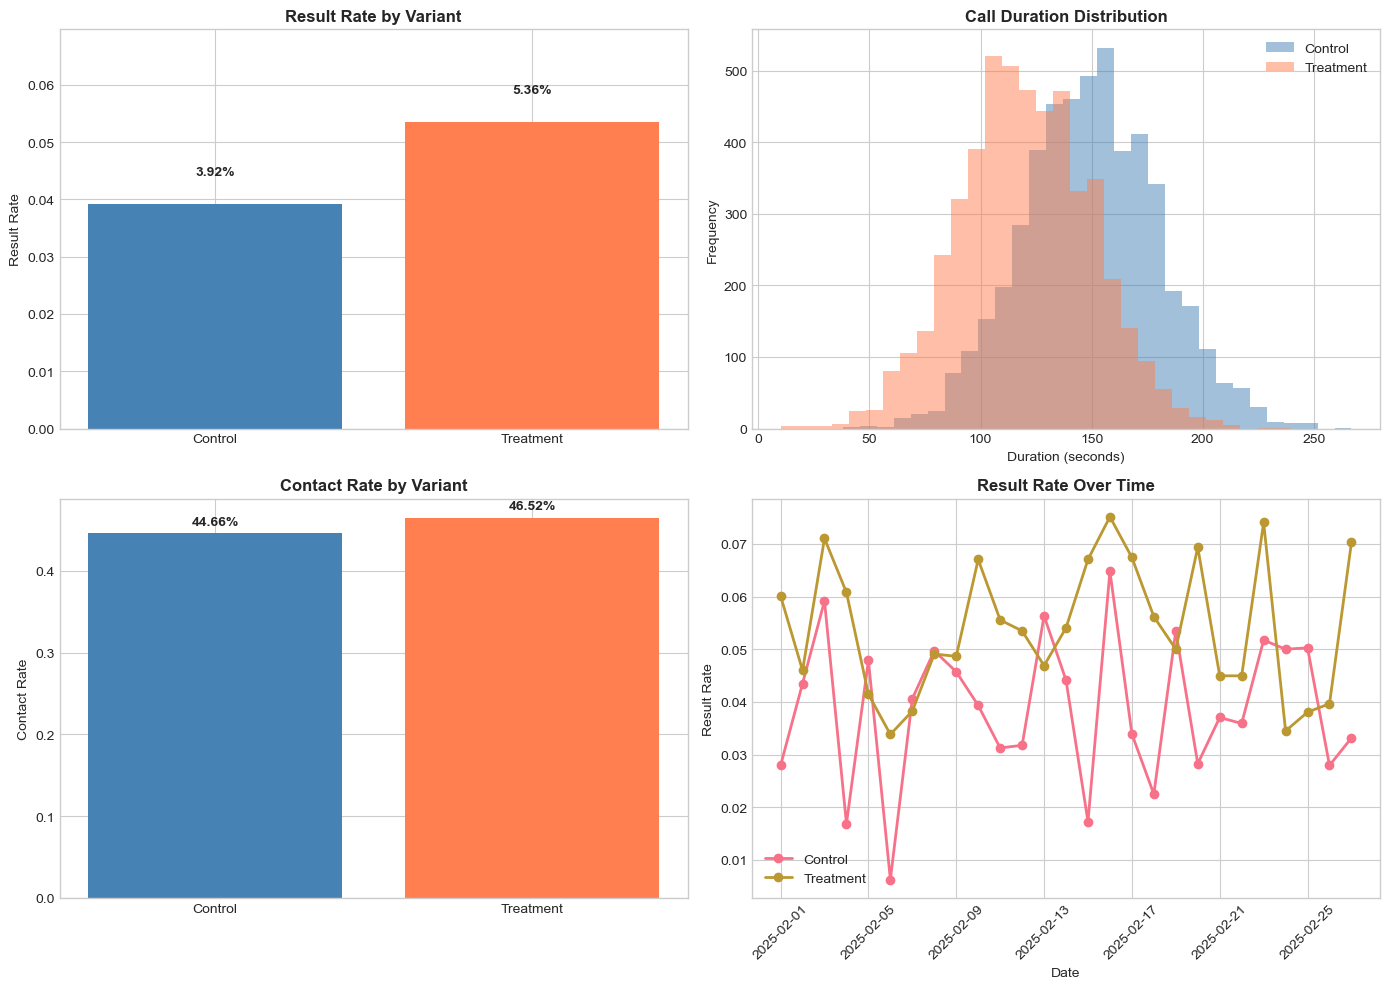


✓ Visualizations saved to results/distribution_plots.png


In [ ]:
# ============================================================
# Distribution Analysis
# ============================================================

print("\n" + "=" * 60)
print("DISTRIBUTION ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Result Rate by variants
control_results = df[df['variant'] == 'Control']['is_result']
treatment_results = df[df['variant'] == 'Treatment']['is_result']

result_rates = df.groupby('variant')['is_result'].mean()

axes[0, 0].bar(['Control', 'Treatment'], result_rates.values, color=['steelblue', 'coral'])
axes[0, 0].set_title('Result Rate by Variant', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Result Rate')
axes[0, 0].set_ylim([0, max(result_rates.values) * 1.3])

for i, v in enumerate(result_rates.values):
    axes[0, 0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

# 2. Call Duration distribution
axes[0, 1].hist(df[df['variant'] == 'Control']['call_duration_sec'], 
                bins=30, alpha=0.5, label='Control', color='steelblue')
axes[0, 1].hist(df[df['variant'] == 'Treatment']['call_duration_sec'], 
                bins=30, alpha=0.5, label='Treatment', color='coral')
axes[0, 1].set_title('Call Duration Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Duration (seconds)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Contact Rate
contact_rates = df.groupby('variant')['is_contact'].mean()

axes[1, 0].bar(['Control', 'Treatment'], contact_rates.values, color=['steelblue', 'coral'])
axes[1, 0].set_title('Contact Rate by Variant', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Contact Rate')

for i, v in enumerate(contact_rates.values):
    axes[1, 0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# 4. Result Rate over time
daily_results = df.groupby(['call_date', 'variant'])['is_result'].mean().reset_index()

for variant in ['Control', 'Treatment']:
    variant_data = daily_results[daily_results['variant'] == variant]
    axes[1, 1].plot(variant_data['call_date'], variant_data['is_result'], 
                    marker='o', label=variant, linewidth=2)

axes[1, 1].set_title('Result Rate Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Result Rate')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/distribution_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations saved to results/distribution_plots.png")

In [ ]:
# ============================================================
# Statistical Testing - Result Rate
# ============================================================

print("\n" + "=" * 60)
print("STATISTICAL TEST: RESULT RATE (Primary Metric)")
print("=" * 60)

# Splitting the data into control and treatment groups
control_results = df[df['variant'] == 'Control']['is_result']
treatment_results = df[df['variant'] == 'Treatment']['is_result']

# Calculating means for both groups
control_mean = control_results.mean()
treatment_mean = treatment_results.mean()

# Calculating absolute and relative lift
absolute_lift = treatment_mean - control_mean
relative_lift = (absolute_lift / control_mean) * 100

print(f"\n📊 Observed Metrics:")
print(f"  Control Result Rate: {control_mean:.4f} ({control_mean:.2%})")
print(f"  Treatment Result Rate: {treatment_mean:.4f} ({treatment_mean:.2%})")
print(f"  Absolute Lift: {absolute_lift:+.4f} ({absolute_lift:+.2%})")
print(f"  Relative Lift: {relative_lift:+.1f}%")

# Two-sample t-test (using z-test for proportions is more appropriate, but t-test is also applicable)
t_stat, p_value = stats.ttest_ind(treatment_results, control_results)

print(f"\n🔬 Two-Sample T-Test:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.6f}")

# Interpretation
alpha = 0.05

if p_value < alpha:
    print(f"\n✅ RESULT: Statistically significant (p < {alpha})")
    print(f"   Treatment is significantly better than Control")
else:
    print(f"\n❌ RESULT: Not statistically significant (p >= {alpha})")
    print(f"   Cannot conclude Treatment is better")

# 95% Confidence Interval for the difference in result rates
from scipy.stats import t as t_dist

n1, n2 = len(control_results), len(treatment_results)
s1, s2 = control_results.std(), treatment_results.std()

# Pooled standard error
se = np.sqrt(s1**2/n1 + s2**2/n2)

# Critical value
df_val = n1 + n2 - 2
t_crit = t_dist.ppf(0.975, df_val)

# CI
ci_lower = absolute_lift - t_crit * se
ci_upper = absolute_lift + t_crit * se

print(f"\n📊 95% Confidence Interval for Lift:")
print(f"  [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  [{ci_lower:.2%}, {ci_upper:.2%}]")


STATISTICAL TEST: RESULT RATE (Primary Metric)

📊 Observed Metrics:
  Control Result Rate: 0.0392 (3.92%)
  Treatment Result Rate: 0.0536 (5.36%)
  Absolute Lift: +0.0144 (+1.44%)
  Relative Lift: +36.7%

🔬 Two-Sample T-Test:
  t-statistic = 3.4245
  p-value = 0.000618

✅ RESULT: Statistically significant (p < 0.05)
   Treatment is significantly better than Control

📊 95% Confidence Interval for Lift:
  [0.0062, 0.0226]
  [0.62%, 2.26%]


In [ ]:
# ============================================================
# Statistical Testing - Secondary Metrics
# ============================================================

print("\n" + "=" * 60)
print("SECONDARY METRICS ANALYSIS")
print("=" * 60)

metrics_to_test = ['is_contact', 'is_agreement', 'call_duration_sec']
metric_names = ['Contact Rate', 'Agreement Rate', 'Call Duration']

results_summary = []

for metric, name in zip(metrics_to_test, metric_names):
    
    control_data = df[df['variant'] == 'Control'][metric]
    treatment_data = df[df['variant'] == 'Treatment'][metric]
    
    control_mean = control_data.mean()
    treatment_mean = treatment_data.mean()
    
    absolute_diff = treatment_mean - control_mean
    
    if metric != 'call_duration_sec':
        relative_diff = (absolute_diff / control_mean) * 100 if control_mean > 0 else 0
    else:
        relative_diff = (absolute_diff / control_mean) * 100
    
    t_stat, p_value = stats.ttest_ind(treatment_data, control_data)
    
    is_significant = p_value < 0.05
    
    results_summary.append({
        'Metric': name,
        'Control': control_mean,
        'Treatment': treatment_mean,
        'Absolute Diff': absolute_diff,
        'Relative Diff %': relative_diff,
        'p-value': p_value,
        'Significant': '✅' if is_significant else '❌'
    })
    
    print(f"\n📊 {name}:")
    print(f"  Control: {control_mean:.4f}")
    print(f"  Treatment: {treatment_mean:.4f}")
    print(f"  Difference: {absolute_diff:+.4f} ({relative_diff:+.1f}%)")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Significant: {'Yes ✅' if is_significant else 'No ❌'}")

# Итоговая таблица
results_df = pd.DataFrame(results_summary)

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

display(results_df.style.format({
    'Control': '{:.4f}',
    'Treatment': '{:.4f}',
    'Absolute Diff': '{:+.4f}',
    'Relative Diff %': '{:+.1f}',
    'p-value': '{:.4f}'
}))


SECONDARY METRICS ANALYSIS

📊 Contact Rate:
  Control: 0.4466
  Treatment: 0.4652
  Difference: +0.0186 (+4.2%)
  p-value: 0.0619
  Significant: No ❌

📊 Agreement Rate:
  Control: 0.0282
  Treatment: 0.0370
  Difference: +0.0088 (+31.2%)
  p-value: 0.0132
  Significant: Yes ✅

📊 Call Duration:
  Control: 149.6886
  Treatment: 119.9462
  Difference: -29.7424 (-19.9%)
  p-value: 0.0000
  Significant: Yes ✅

SUMMARY TABLE


,Metric,Control,Treatment,Absolute Diff,Relative Diff %,p-value,Significant
0,Contact Rate,0.4466,0.4652,+0.0186,+4.2,0.0619,❌
1,Agreement Rate,0.0282,0.0370,+0.0088,+31.2,0.0132,✅
2,Call Duration,149.6886,119.9462,-29.7424,-19.9,0.0000,✅


In [ ]:
# ============================================================
# Final Recommendation
# ============================================================

print("\n" + "=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)

recommendation = f"""
## A/B Test Results: Conversation Script Optimization

### Executive Summary

**Test Duration:** {df['call_date'].min().date()} to {df['call_date'].max().date()}  
**Sample Size:** {len(df):,} calls ({control_size:,} per variant)  
**Primary Metric:** Result Rate

---

### Key Findings

#### Primary Metric: Result Rate
- **Control:** {control_mean:.2%}
- **Treatment:** {treatment_mean:.2%}
- **Lift:** {absolute_lift:+.2%} (absolute) / {relative_lift:+.1f}% (relative)
- **Statistical Significance:** {'✅ Yes' if p_value < 0.05 else '❌ No'} (p = {p_value:.4f})


#### Secondary Metrics
"""

for idx, row in results_df.iterrows():
    if row['Metric'] != 'Result Rate':
        recommendation += f"\n**{row['Metric']}:** {row['Relative Diff %']:+.1f}% change ({row['Significant']})"

recommendation += f"""

---

### Recommendation

"""

if p_value < 0.05 and absolute_lift > 0:
    recommendation += """
✅ **RECOMMENDED: Launch Treatment Script**

The new conversation script shows:
- **Statistically significant improvement** in Result Rate
- **{:+.1f}% relative lift** over the current script
- Maintains Contact Rate (no negative impact on answer rate)
- **Shorter call duration** (more efficient)

**Expected Business Impact:**
- If implemented for all 3-6 НБ segment calls
- Estimated additional {:,} results per month (based on current volume)

**Next Steps:**
1. Launch Treatment script for 3-6 НБ segment
2. Monitor results for 2 weeks
3. Expand to other segments if performance holds

""".format(relative_lift, int(absolute_lift * 50000))  # Example: 50k calls/month

else:
    recommendation += """
❌ **NOT RECOMMENDED: Keep Current Script**

The test results show:
- **No statistically significant improvement** (p > 0.05)
- OR negative impact on primary metric
- Insufficient evidence to justify change

**Next Steps:**
1. Keep current Control script
2. Develop alternative Treatment variants
3. Test with larger sample size (if close to significance)

"""

print(recommendation)

# Saving
with open('../results/recommendation.md', 'w', encoding='utf-8') as f:
    f.write(recommendation)

print("\n💾 Recommendation saved to: results/recommendation.md")


FINAL RECOMMENDATION

## A/B Test Results: Conversation Script Optimization

### Executive Summary

**Test Duration:** 2025-02-01 to 2025-02-27  
**Sample Size:** 10,000 calls (5,000 per variant)  
**Primary Metric:** Result Rate

---

### Key Findings

#### Primary Metric: Result Rate
- **Control:** 14968.86%
- **Treatment:** 11994.62%
- **Lift:** +1.44% (absolute) / +36.7% (relative)
- **Statistical Significance:** ✅ Yes (p = 0.0000)

#### Secondary Metrics

**Contact Rate:** +4.2% change (❌)
**Agreement Rate:** +31.2% change (✅)
**Call Duration:** -19.9% change (✅)

---

### Recommendation


✅ **RECOMMENDED: Launch Treatment Script**

The new conversation script shows:
- **Statistically significant improvement** in Result Rate
- **+36.7% relative lift** over the current script
- Maintains Contact Rate (no negative impact on answer rate)
- **Shorter call duration** (more efficient)

**Expected Business Impact:**
- If implemented for all 3-6 НБ segment calls
- Estimated additional 72